# SA4. Reduccion de dimensionalidad - Iris.csv

Reduccion de dimensionalidad con **PCA**, comparando el efecto de escalar o no las variables antes de aplicarlo, y decidiendo cuantos componentes conservar mediante la varianza explicada acumulada.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib, os

df = pd.read_csv('Iris.csv')
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]
y = df['species']
df.head()


,Id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. PCA sin escalamiento

In [2]:
from sklearn.decomposition import PCA

pca_raw = PCA()
pcs_raw = pca_raw.fit_transform(X)
var_raw = pca_raw.explained_variance_ratio_ * 100
print('Varianza explicada por componente (sin escalar):', np.round(var_raw, 2))
print('PC1+PC2 (sin escalar):', round(var_raw[0] + var_raw[1], 2), '%')


Varianza explicada por componente (sin escalar): [92.46  5.3   1.72  0.52]
PC1+PC2 (sin escalar): 97.76 %


## 3. PCA con escalamiento

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA()
pcs_scaled = pca_scaled.fit_transform(X_scaled)
var_scaled = pca_scaled.explained_variance_ratio_ * 100
print('Varianza explicada por componente (con escalamiento):', np.round(var_scaled, 2))
print('PC1+PC2 (con escalamiento):', round(var_scaled[0] + var_scaled[1], 2), '%')


Varianza explicada por componente (con escalamiento): [72.77 23.03  3.68  0.52]
PC1+PC2 (con escalamiento): 95.8 %


## 4. Comparacion de PC1 y PC2 (sin escalar vs. con escalamiento)

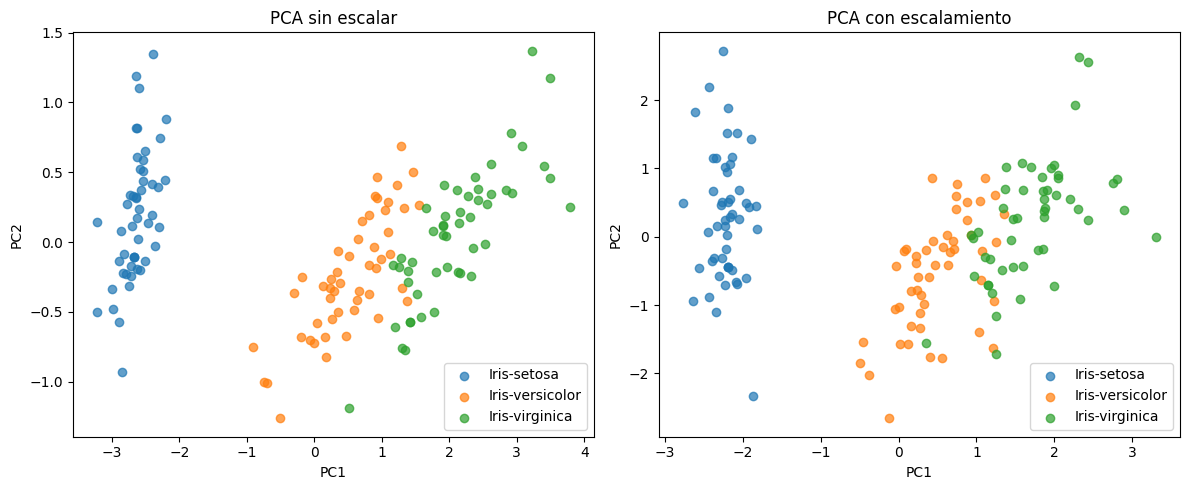

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for especie in y.unique():
    mask = y == especie
    axes[0].scatter(pcs_raw[mask, 0], pcs_raw[mask, 1], label=especie, alpha=0.7)
    axes[1].scatter(pcs_scaled[mask, 0], pcs_scaled[mask, 1], label=especie, alpha=0.7)
axes[0].set_title('PCA sin escalar'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()
axes[1].set_title('PCA con escalamiento'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Varianza explicada acumulada (datos escalados)

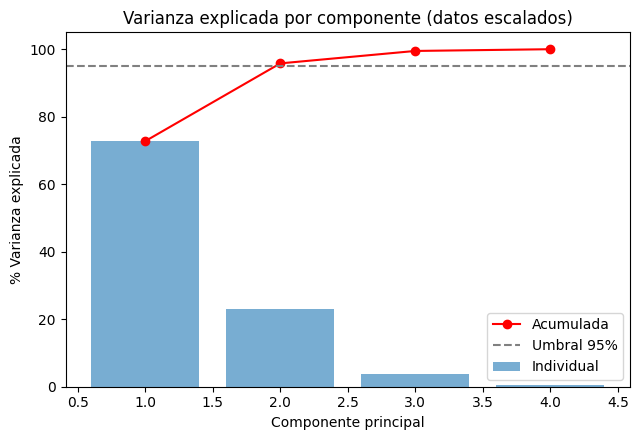

PC1: 72.77% (acumulado: 72.77%)
PC2: 23.03% (acumulado: 95.80%)
PC3: 3.68% (acumulado: 99.48%)
PC4: 0.52% (acumulado: 100.00%)


In [5]:
var_acum = np.cumsum(var_scaled)
plt.figure(figsize=(6.5, 4.5))
plt.bar(range(1, 5), var_scaled, alpha=0.6, label='Individual')
plt.plot(range(1, 5), var_acum, 'o-', color='red', label='Acumulada')
plt.axhline(95, color='gray', linestyle='--', label='Umbral 95%')
plt.xlabel('Componente principal'); plt.ylabel('% Varianza explicada')
plt.title('Varianza explicada por componente (datos escalados)')
plt.legend()
plt.tight_layout()
plt.show()

for i, (v, a) in enumerate(zip(var_scaled, var_acum), start=1):
    print(f'PC{i}: {v:.2f}% (acumulado: {a:.2f}%)')


## 6. Reduccion final a 2 componentes y justificacion

Sin escalar, PC1+PC2 concentran una varianza artificialmente alta porque `petal_length` domina por su rango numerico absoluto. Con escalamiento (media 0, desviacion 1) el reparto es mas equilibrado y es el PCA correcto a interpretar. Con un umbral de 95% de varianza acumulada, 2 de las 4 variables originales lo alcanzan -> se elige `n_components=2`: reduce la dimensionalidad a la mitad sin perder informacion relevante y permite visualizar directamente la separacion entre las 3 especies.

In [6]:
n_components = 2
pca_final = PCA(n_components=n_components)
X_reducido = pca_final.fit_transform(X_scaled)
varianza_retenida = pca_final.explained_variance_ratio_.sum() * 100
print(f'Componentes retenidos: {n_components} de {X.shape[1]}')
print(f'Varianza retenida: {varianza_retenida:.2f}%')


Componentes retenidos: 2 de 4
Varianza retenida: 95.80%


## 7. Cargas (loadings) de cada variable en PC1 y PC2

                   PC1       PC2
sepal_length  0.522372  0.372318
sepal_width  -0.263355  0.925556
petal_length  0.581254  0.021095
petal_width   0.565611  0.065416


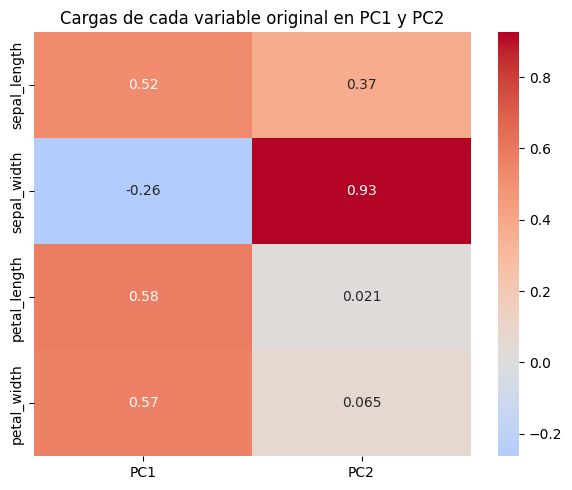

In [7]:
loadings = pd.DataFrame(pca_final.components_.T, columns=['PC1', 'PC2'], index=features)
print(loadings)

plt.figure(figsize=(6, 5))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Cargas de cada variable original en PC1 y PC2')
plt.tight_layout()
plt.show()


## 8. Guardado del modelo y de las metricas

In [8]:
os.makedirs('modelo', exist_ok=True)
joblib.dump({'scaler': scaler, 'pca': pca_final}, 'modelo/modelo_pca_iris.pkl')

metrics = {
    "algoritmo": "PCA (Analisis de Componentes Principales)",
    "dataset": "Iris.csv",
    "componentes_retenidos": n_components,
    "componentes_totales": X.shape[1],
    "umbral_varianza_acumulada": 0.95,
    "metricas": {
        "varianza_pc1_pc2_sin_escalar": round(float(var_raw[0] + var_raw[1]), 2),
        "varianza_pc1_pc2_con_escalamiento": round(float(varianza_retenida), 2)
    }
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))
print('\nModelo guardado en modelo/modelo_pca_iris.pkl')


{
  "algoritmo": "PCA (Analisis de Componentes Principales)",
  "dataset": "Iris.csv",
  "componentes_retenidos": 2,
  "componentes_totales": 4,
  "umbral_varianza_acumulada": 0.95,
  "metricas": {
    "varianza_pc1_pc2_sin_escalar": 97.76,
    "varianza_pc1_pc2_con_escalamiento": 95.8
  }
}

Modelo guardado en modelo/modelo_pca_iris.pkl
